In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import scipy
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
from collections import Counter
import scipy.sparse as sp
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

sc.settings.verbosity = 2
# sc.logging.print_header()

# Load in exo vs endo adata

In [2]:
%%time

fpath = "/scratch/indikar_root/indikar1/shared_data/HYB/endo_vs_exo/processed_all_groups_wExoEndo_v2.h5ad"

adata = sc.read_h5ad(fpath)
adata

CPU times: user 708 ms, sys: 2.24 s, total: 2.94 s
Wall time: 10.6 s


AnnData object with n_obs × n_vars = 16296 × 25128
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

# Extract endo/exo counts

In [3]:
### ------ get EXO/ENDO counts ------

adata.X = adata.layers['log_norm'].copy()


genes = ['MYOD1_exo', 'MYOD1_endo']

mdata = adata[:, genes].copy()
print(mdata.shape)


X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()

df = pd.DataFrame(
        X,
        index=mdata.obs_names,
        columns=mdata.var_names,
    )


df = df.reset_index(names='cell_id')
print(df.shape)
df.head()


tmp = adata.obs[['pooled_condition', 'leiden_split', 'phase']].copy()

tmp = tmp.reset_index(names='cell_id')


df1 = pd.merge(df, tmp, how='left', on='cell_id')
print(df1.shape)
df1.head()

(16296, 2)
(16296, 3)
(16296, 6)


,cell_id,MYOD1_exo,MYOD1_endo,pooled_condition,leiden_split,phase
0,AAACCAAAGCAACTGC_hybrid,3.913242,3.309699,siPRRX1/mmMYOD1,H1,G2M
1,AAACCAAAGTAGGGCA_hybrid,3.809541,3.160314,mmMYOD1,M1,S
2,AAACCAAAGTCTAGGC_hybrid,2.587936,2.244517,siPRRX1/mmMYOD1,H1,G1
3,AAACCATTCACGTAAT_hybrid,0.000000,0.000000,siPRRX1,P1,G2M
4,AAACCATTCAGGCAGA_hybrid,0.000000,0.000000,siPRRX1,P1,G2M


# Bin MYOD1 expression

In [4]:
### 
# group cells by HIGH / LOW MYOD1 expression
pdf = df1.copy()

pdf['avg_MYOD1'] = (pdf['MYOD1_exo'] + pdf['MYOD1_endo']) / 2


print("Total MYOD1 expression:")
print(f"Mean = {pdf['avg_MYOD1'].mean():.4f}, Median = {pdf['avg_MYOD1'].median()}\n")

print("Among positive MYOD1 expression:")
print(f"Mean = {pdf[pdf['avg_MYOD1'] > 0]['avg_MYOD1'].mean():.4f}, Median = {pdf[pdf['avg_MYOD1'] > 0]['avg_MYOD1'].median():.4f}\n")


cond_col = "pooled_condition" 
labels = ["low", "med", "high"]

pdf["exp_level"] = "NE"

pos_mask = pdf["avg_MYOD1"] > 0


def assign_tertiles_within_group(s):
    # s is avg_MYOD1 for positive cells in ONE condition
    if s.nunique() < 2:
        # not enough unique values to form quantiles reliably
        return pd.Series(["med"] * len(s), index=s.index)

    # Use rank to break ties deterministically so qcut can make equal counts
    r = s.rank(method="first")
    out = pd.qcut(r, q=3, labels=labels)
    return out.astype(str)

pdf.loc[pos_mask, "exp_level"] = (
    pdf.loc[pos_mask]
       .groupby(cond_col)["avg_MYOD1"]
       .apply(assign_tertiles_within_group)
       .reset_index(level=0, drop=True)
)

# checks: equal-sized tertiles per condition among positives
print(pdf.loc[pos_mask].groupby(cond_col)["exp_level"].value_counts())

Total MYOD1 expression:
Mean = 1.0107, Median = 0.0

Among positive MYOD1 expression:
Mean = 2.5790, Median = 2.6923

pooled_condition  exp_level
Control           high            0
                  low             0
                  med             0
mmMYOD1           high          749
                  low           748
                  med           748
siPRRX1           high          260
                  low           260
                  med           259
siPRRX1/mmMYOD1   high         1121
                  low          1121
                  med          1120
Name: count, dtype: int64


/tmp/ipykernel_3755049/3050846993.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cond_col)["avg_MYOD1"]
/tmp/ipykernel_3755049/3050846993.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(pdf.loc[pos_mask].groupby(cond_col)["exp_level"].value_counts())


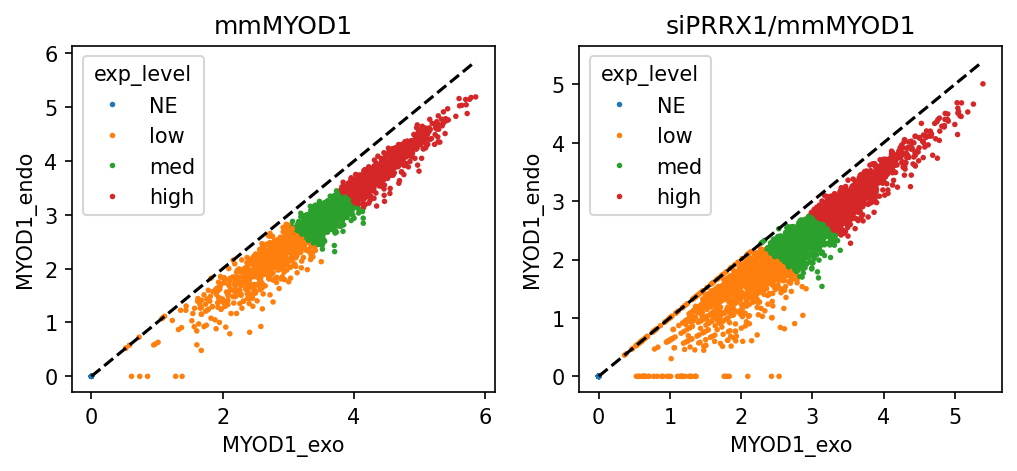

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=150)
axes = axes.flatten()

conds_to_plot = ['mmMYOD1', 'siPRRX1/mmMYOD1']

for i, cond in enumerate(conds_to_plot):
    ax = axes[i]
    
    tmp = pdf[pdf['pooled_condition'] == cond].copy()
    
    sns.scatterplot(
        tmp,
        x='MYOD1_exo',
        y='MYOD1_endo',
        hue='exp_level',
        hue_order=['NE', 'low', 'med', 'high'],
        s=7,
        ec='none',
        ax=ax,
    )
    
    ax.set_title(f'{cond}')
    
    # Identity line
    min_val = min(tmp['MYOD1_exo'].min(), tmp['MYOD1_endo'].min())
    max_val = max(tmp['MYOD1_exo'].max(), tmp['MYOD1_endo'].max())
    
    ax.plot([min_val, max_val], [min_val, max_val], ls='--', color='black')
    
    
plt.show()

In [59]:
### 
# group cells by HIGH / LOW MYOD1 expression
pdf = df1.copy()


pdf = pdf[pdf['pooled_condition'].isin(['mmMYOD1', 'siPRRX1/mmMYOD1'])]


pdf['avg_MYOD1'] = (pdf['MYOD1_exo'] + pdf['MYOD1_endo']) / 2


print("Total MYOD1 expression:")
print(f"Mean = {pdf['avg_MYOD1'].mean():.4f}, Median = {pdf['avg_MYOD1'].median()}\n")

print("Among positive MYOD1 expression:")
print(f"Mean = {pdf[pdf['avg_MYOD1'] > 0]['avg_MYOD1'].mean():.4f}, Median = {pdf[pdf['avg_MYOD1'] > 0]['avg_MYOD1'].median():.4f}\n")


# cond_col = "pooled_condition" 
labels = ["low", "med", "high"]

pdf["exp_level"] = "NE"

pos_mask = pdf["avg_MYOD1"] > 0

# rank to break ties (important for qcut stability)
r = pdf.loc[pos_mask, "avg_MYOD1"].rank(method="first")

pdf.loc[pos_mask, "exp_level"] = pd.qcut(
    r,
    q=3,
    labels=labels
).astype(str)

print(pdf['exp_level'].value_counts())
print(pdf.groupby('pooled_condition', observed=False)['exp_level'].value_counts())
pdf.head()

Total MYOD1 expression:
Mean = 2.7695, Median = 2.807445509987801

Among positive MYOD1 expression:
Mean = 2.8208, Median = 2.8253

exp_level
high    1869
low     1869
med     1869
NE       104
Name: count, dtype: int64
pooled_condition  exp_level
Control           NE              0
                  high            0
                  low             0
                  med             0
mmMYOD1           high         1222
                  med           642
                  low           381
                  NE             10
siPRRX1           NE              0
                  high            0
                  low             0
                  med             0
siPRRX1/mmMYOD1   low          1488
                  med          1227
                  high          647
                  NE             94
Name: count, dtype: int64


,cell_id,MYOD1_exo,MYOD1_endo,pooled_condition,leiden_split,phase,avg_MYOD1,exp_level
0,AAACCAAAGCAACTGC_hybrid,3.913242,3.309699,siPRRX1/mmMYOD1,H1,G2M,3.611470,high
1,AAACCAAAGTAGGGCA_hybrid,3.809541,3.160314,mmMYOD1,M1,S,3.484927,high
2,AAACCAAAGTCTAGGC_hybrid,2.587936,2.244517,siPRRX1/mmMYOD1,H1,G1,2.416226,low
5,AAACCATTCCGTAATG_hybrid,3.385067,2.862861,siPRRX1/mmMYOD1,H2,G2M,3.123964,med
6,AAACCCGCACCATAGG_hybrid,3.201587,2.848171,mmMYOD1,M2,G1,3.024879,med


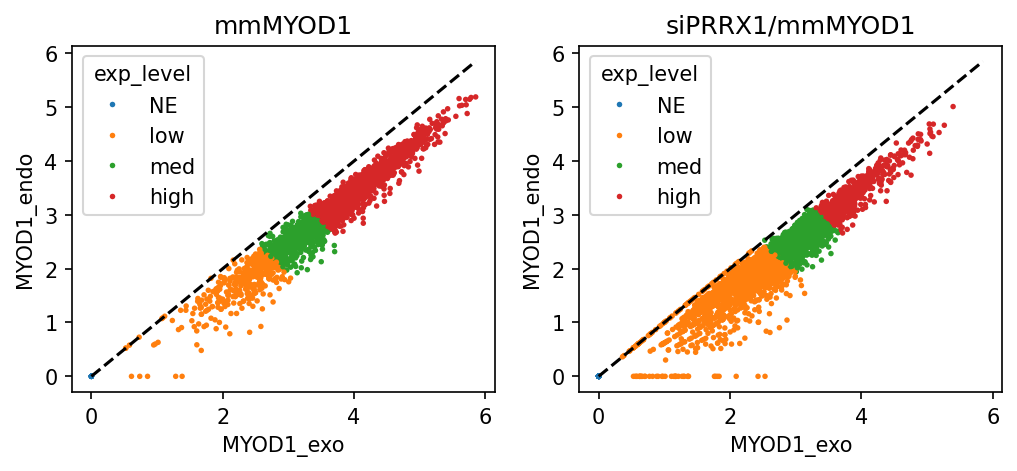

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=150)
axes = axes.flatten()

conds_to_plot = ['mmMYOD1', 'siPRRX1/mmMYOD1']

for i, cond in enumerate(conds_to_plot):
    ax = axes[i]
    
    tmp = pdf[pdf['pooled_condition'] == cond].copy()
    
    sns.scatterplot(
        tmp,
        x='MYOD1_exo',
        y='MYOD1_endo',
        hue='exp_level',
        hue_order=['NE', 'low', 'med', 'high'],
        s=7,
        ec='none',
        ax=ax,
    )
    
    ax.set_title(f'{cond}')
    
    # Identity line
    min_val = min(pdf['MYOD1_exo'].min(), pdf['MYOD1_endo'].min())
    max_val = max(pdf['MYOD1_exo'].max(), pdf['MYOD1_endo'].max())
    
    ax.plot([min_val, max_val], [min_val, max_val], ls='--', color='black')
    
    
plt.show()

In [63]:
### --------- add exp_level to adata.obs ---------

# make a Series indexed by cell_id
s = (pdf.set_index("cell_id")["exp_level"])

# align to adata.obs_names and add
adata.obs["exp_level"] = s.reindex(adata.obs_names)

# (optional) keep ordered categorical + desired order
exp_bins = ["NE", "low", "med", "high"]
adata.obs["exp_level"] = pd.Categorical(adata.obs["exp_level"],
                                        categories=exp_bins,
                                        ordered=True)

# quick sanity checks
print(adata.obs["exp_level"].isna().sum(), "cells missing exp_level (no match in pdf)")
print(adata.obs["exp_level"].value_counts(dropna=False))

10585 cells missing exp_level (no match in pdf)
exp_level
NaN     10585
med      1869
low      1869
high     1869
NE        104
Name: count, dtype: int64


# Load gene sets of interest

Cell cycle

Stress 
* ER stress
* Oxidative stress
* DNA damage response
* Heat shock proteins

In [8]:
### GO biological processes
path_2023 = "../resources/GO_Biological_Process_2023.txt"
path_2025 = "/home/jrcwycy/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt"

geneset_dict = {}

with open(path_2025, "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 1:
            term = parts[0].strip()
            genes = parts[2:] if len(parts) > 2 else []
            genes = [g.strip() for g in genes if g.strip()]
            geneset_dict[term] = genes

geneset = pd.DataFrame.from_dict(geneset_dict, orient='index').T
geneset.head()

,'De Novo' AMP Biosynthetic Process (GO:0044208),'De Novo' Post-Translational Protein Folding (GO:0051084),2-Oxoglutarate Metabolic Process (GO:0006103),3'-UTR-mediated mRNA Destabilization (GO:0061158),3'-UTR-mediated mRNA Stabilization (GO:0070935),3'-Phosphoadenosine 5'-Phosphosulfate Metabolic Process (GO:0050427),4-Hydroxyproline Metabolic Process (GO:0019471),5S Class rRNA Transcription by RNA Polymerase III (GO:0042791),7-Methylguanosine RNA Capping (GO:0009452),7-Methylguanosine Cap Hypermethylation (GO:0036261),...,Wybutosine Biosynthetic Process (GO:0031591),Wybutosine Metabolic Process (GO:0031590),Xenobiotic Catabolic Process (GO:0042178),Xenobiotic Transport (GO:0042908),Xenobiotic Transport Across Blood-Brain Barrier (GO:1990962),Zinc Ion Import Across Plasma Membrane (GO:0071578),Zinc Ion Import Into Organelle (GO:0062111),Zinc Ion Transmembrane Transport (GO:0071577),Zinc Ion Transport (GO:0006829),Zymogen Activation (GO:0031638)
0,ATIC,CCT4,IDH1,UPF1,RBM38,PAPSS1,EGLN2,GTF3C2,RNGTT,SNRPD3,...,TYW5,TYW5,UGT1A10,ABCC5,ABCC2,SLC30A8,SLC30A8,SLC30A8,SLC30A8,FGB
1,PAICS,SDF2L1,PHYH,TRIM71,DAZ4,PAPSS2,GOT2,GTF3C3,RNMT,SNRPD2,...,TYW3,TYW3,GSTM4,SLC22A4,SLC22A1,SLC39A10,SLC30A7,SLC39A1,SLC39A1,FGG
2,PFAS,CCT3,GOT2,RC3H1,TIRAP,SULT1A2,HOGA1,GTF3C4,NCBP1,SNRPF,...,TYW1,TYW1,GSTM3,ABCB1,SLC22A2,SLC39A12,SLC30A4,SLC30A4,SLC30A9,F12
3,ADSS1,HSPA9,IDH2,ZFP36L1,DAZ3,SULT1C4,P4HB,GTF3C5,CMTR2,SNRPG,...,TRMT12,TRMT12,GSTM2,ABCC2,ABCC1,SLC39A6,SLC30A3,SLC30A3,SLC30A4,ZNF160
4,ADSS2,CCT2,ADHFE1,PUM2,YBX3,SULT2A1,PRODH,GTF3C6,RAMAC,SNRPE,...,TYW1B,TYW1B,NANOS1,SLC15A2,ABCG2,SLC39A14,SLC30A6,SLC30A5,SLC30A3,F9


In [9]:
[col for col in geneset if 'stress' in col.lower()]

['Cellular Response to Chemical Stress (GO:0062197)',
 'Cellular Response to Fluid Shear Stress (GO:0071498)',
 'Cellular Response to Laminar Fluid Shear Stress (GO:0071499)',
 'Cellular Response to Osmotic Stress (GO:0071470)',
 'Cellular Response to Oxidative Stress (GO:0034599)',
 'Integrated Stress Response Signaling (GO:0140467)',
 'Intrinsic Apoptotic Signaling Pathway in Response to Endoplasmic Reticulum Stress (GO:0070059)',
 'Intrinsic Apoptotic Signaling Pathway in Response to Oxidative Stress (GO:0008631)',
 'Negative Regulation of Cardiac Muscle Hypertrophy in Response to Stress (GO:1903243)',
 '- Reg of Endoplasmic Reticulum Stress-Induced Intrinsic Apoptotic Sgnlng Pway (GO:1902236)',
 'Negative Regulation of Oxidative Stress-Induced Intrinsic Apoptotic Signaling Pathway (GO:1902176)',
 '- Reg of Oxidative Stress-Induced Neuron Intrinsic Apoptotic Sgnlng Pway (GO:1903377)',
 'Negative Regulation of Response to Endoplasmic Reticulum Stress (GO:1903573)',
 'Negative Regulat

In [17]:
### ---- Oxidative stress ----
oxi_stress_terms = [
    'Cellular Response to Oxidative Stress (GO:0034599)',
    'Regulation of Response to Oxidative Stress (GO:1902882)',
    'Regulation of Cellular Response to Oxidative Stress (GO:1900407)',
]
oxi_stress_genes = list(set(geneset[oxi_stress_terms].stack().tolist()))
print(f'N oxidative stress genes: {len(oxi_stress_genes)}')


### ---- ER stress ----
er_stress_terms = [
    'Positive Regulation of Response to Endoplasmic Reticulum Stress (GO:1905898)',
    'Response to Endoplasmic Reticulum Stress (GO:0034976)',
    'Regulation of Translation in Response to Endoplasmic Reticulum Stress (GO:0036490)',
    'Regulation of Response to Endoplasmic Reticulum Stress (GO:1905897)',
]
er_stress_genes = list(set(geneset[er_stress_terms].stack().tolist()))
print(f'N ER stress genes: {len(er_stress_genes)}')


### ---- general stress ----
stress_terms = [
    'Regulation of Cellular Response to Stress (GO:0080135)',
    'Regulation of Response to Stress (GO:0080134)',
    'Positive Regulation of Translation in Response to Stress (GO:0032056)',
]
stress_genes = list(set(geneset[stress_terms].stack().tolist()))
print(f'N ER stress genes: {len(stress_genes)}')


### ---- integrated stress response ----
isr_genes = list(set(geneset[['Integrated Stress Response Signaling (GO:0140467)']].stack().tolist()))
print(f'N integrated stress response genes: {len(isr_genes)}')


### ---- positive apoptosis ----  
pos_apop_terms = [
    'Positive Regulation of Apoptotic Cell Clearance (GO:2000427)',
    'Positive Regulation of Apoptotic Process (GO:0043065)',
    'Positive Regulation of Apoptotic Signaling Pathway (GO:2001235)',
    '+ Reg of Endoplasmic Reticulum Stress-Induced Intrinsic Apoptotic Sgnlng Pway (GO:1902237)',
    'Positive Regulation of Extrinsic Apoptotic Signaling Pathway (GO:2001238)',
    'Positive Regulation of Fibroblast Apoptotic Process (GO:2000271)',
    'Positive Regulation of Intrinsic Apoptotic Signaling Pathway (GO:2001244)',
    'Positive Regulation of Intrinsic Apoptotic Signaling Pathway by P53 Class Mediator (GO:1902255)',
    'Positive Regulation of Execution Phase of Apoptosis (GO:1900119)',
]
df = geneset[pos_apop_terms]
pos_apop_genes = list(set(df.stack().tolist()))
print(f"N pos apoptosis genes: {len(pos_apop_genes)}\n")


N oxidative stress genes: 134
N ER stress genes: 218
N ER stress genes: 121
N integrated stress response genes: 34
N pos apoptosis genes: 365



In [10]:
[col for col in geneset if 'dna damage' in col.lower()]

['DNA Damage Checkpoint Signaling (GO:0000077)',
 'DNA Damage Response (GO:0006974)',
 'DNA Damage Response, Signal Transduction by P53 Class Mediator (GO:0030330)',
 'Intrinsic Apoptotic Signaling Pathway in Response to DNA Damage (GO:0008630)',
 'Intrinsic Apoptotic Signaling Pathway in Response to DNA Damage by P53 Class Mediator (GO:0042771)',
 'Mitotic DNA Damage Checkpoint Signaling (GO:0044773)',
 'Mitotic G1 DNA Damage Checkpoint Signaling (GO:0031571)',
 'Mitotic G2 DNA Damage Checkpoint Signaling (GO:0007095)',
 'Mitotic intra-S DNA Damage Checkpoint Signaling (GO:0031573)',
 'Negative Regulation of DNA Damage Response, Signal Transduction by P53 Class Mediator (GO:0043518)',
 'Negative Regulation of Intrinsic Apoptotic Signaling Pathway in Response to DNA Damage (GO:1902230)',
 '- Reg of Intrinsic Apoptotic Sgnlng Pway in Resp to DNA Damage by P53 Cls Mediator (GO:1902166)',
 'Positive Regulation of DNA Damage Response, Signal Transduction by P53 Class Mediator (GO:0043517)'

In [15]:
### ---- DNA damage response (DDR) ---- 
ddr_terms = [
    'DNA Damage Response (GO:0006974)',
    'DNA Damage Response, Signal Transduction by P53 Class Mediator (GO:0030330)',
    'Positive Regulation of DNA Damage Response, Signal Transduction by P53 Class Mediator (GO:0043517)',
    'Regulation of DNA Damage Response, Signal Transduction by P53 Class Mediator (GO:0043516)',
]

ddr_genes = list(set(geneset[ddr_terms].stack().tolist()))
print(f'N DNA damage response genes: {len(ddr_genes)}')

N DNA damage response genes: 468


In [81]:
mdf = pd.read_json("../../resources/HALLMARK_MYOGENESIS.v2026.1.Hs.json")
myogenesis = mdf.loc['geneSymbols', 'HALLMARK_MYOGENESIS']
print(f'Total HALLMARK_MYOGENESIS genes: {len(myogenesis)}')



ppdf = pd.read_json("../../resources/HALLMARK_P53_PATHWAY.v2026.1.Hs.json")
p53_genes = ppdf.loc['geneSymbols', 'HALLMARK_P53_PATHWAY']
print(f'Total HALLMARK_P53_PATHWAY genes: {len(p53_genes)}')


rdf = pd.read_json("../../resources/HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY.v2026.1.Hs.json")
ros_genes = rdf.loc['geneSymbols', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY']
print(f'Total HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY genes: {len(ros_genes)}')


udf = pd.read_json("../../resources/HALLMARK_UNFOLDED_PROTEIN_RESPONSE.v2026.1.Hs.json")
upr_genes = udf.loc['geneSymbols', 'HALLMARK_UNFOLDED_PROTEIN_RESPONSE']
print(f'Total HALLMARK_UNFOLDED_PROTEIN_RESPONSE genes: {len(upr_genes)}')

Total HALLMARK_MYOGENESIS genes: 200
Total HALLMARK_P53_PATHWAY genes: 200
Total HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY genes: 49
Total HALLMARK_UNFOLDED_PROTEIN_RESPONSE genes: 113


In [88]:
### Combine into 1 data object
categories = {
    'oxidative_stress': oxi_stress_genes,
    'ER_stress': er_stress_genes,
    'general_stress': stress_genes,
    'int_stress_response': isr_genes,
    'pos_apoptosis': pos_apop_genes,
    'DNA_damage_response': ddr_genes,
    'p53_pathway': p53_genes,
    'ROS': ros_genes,
    'UPR': upr_genes,
    'myogenesis': myogenesis,
}

for key, gene_list in categories.items():
    print(f"N genes for {key}: {len(gene_list)}")
    
# make into a dataframe
cleaned_categories = {k: list(np.ravel(v)) for k, v in categories.items()}
max_len = max(len(v) for v in cleaned_categories.values())
padded = {k: v + [None] * (max_len - len(v)) for k, v in cleaned_categories.items()}

cdf = pd.DataFrame(padded)
cdf.head()

N genes for oxidative_stress: 134
N genes for ER_stress: 218
N genes for general_stress: 121
N genes for int_stress_response: 34
N genes for pos_apoptosis: 365
N genes for DNA_damage_response: 468
N genes for p53_pathway: 200
N genes for ROS: 49
N genes for UPR: 113
N genes for myogenesis: 200


,oxidative_stress,ER_stress,general_stress,int_stress_response,pos_apoptosis,DNA_damage_response,p53_pathway,ROS,UPR,myogenesis
0,EIF2S1,EIF2S1,AIFM2,EIF2S1,RBM5,KMT5A,ABAT,ABCC1,ALDH18A1,ABLIM1
1,AIFM2,RNF183,SF3B5,QRICH1,PRR7,DTX3L,ABCC5,ATOX1,ARFGAP1,ACHE
2,ZC3H12A,NCK2,KMT5A,IMPACT,PPID,SHLD3,ABHD4,CAT,ASNS,ACSL1
3,PRKAA1,CDK5RAP3,NCK2,BATF,TRIM35,FANCL,ACVR1B,CDKN2D,ATF3,ACTA1
4,SIRT2,BOK,UBE2N,MAF,RRP1B,REXO4,ADA,EGLN2,ATF4,ACTC1


In [89]:
score_names = [col + '_score' for col in cdf.columns]
score_names

['oxidative_stress_score',
 'ER_stress_score',
 'general_stress_score',
 'int_stress_response_score',
 'pos_apoptosis_score',
 'DNA_damage_response_score',
 'p53_pathway_score',
 'ROS_score',
 'UPR_score',
 'myogenesis_score']

Skipping oxidative_stress, scores already exist.
Skipping ER_stress, scores already exist.
Skipping general_stress, scores already exist.
Skipping int_stress_response, scores already exist.
Skipping pos_apoptosis, scores already exist.
Skipping DNA_damage_response, scores already exist.
Skipping p53_pathway, scores already exist.
Skipping ROS, scores already exist.
Skipping UPR, scores already exist.
computing score 'myogenesis_score'
    finished (0:00:03)
Finished.


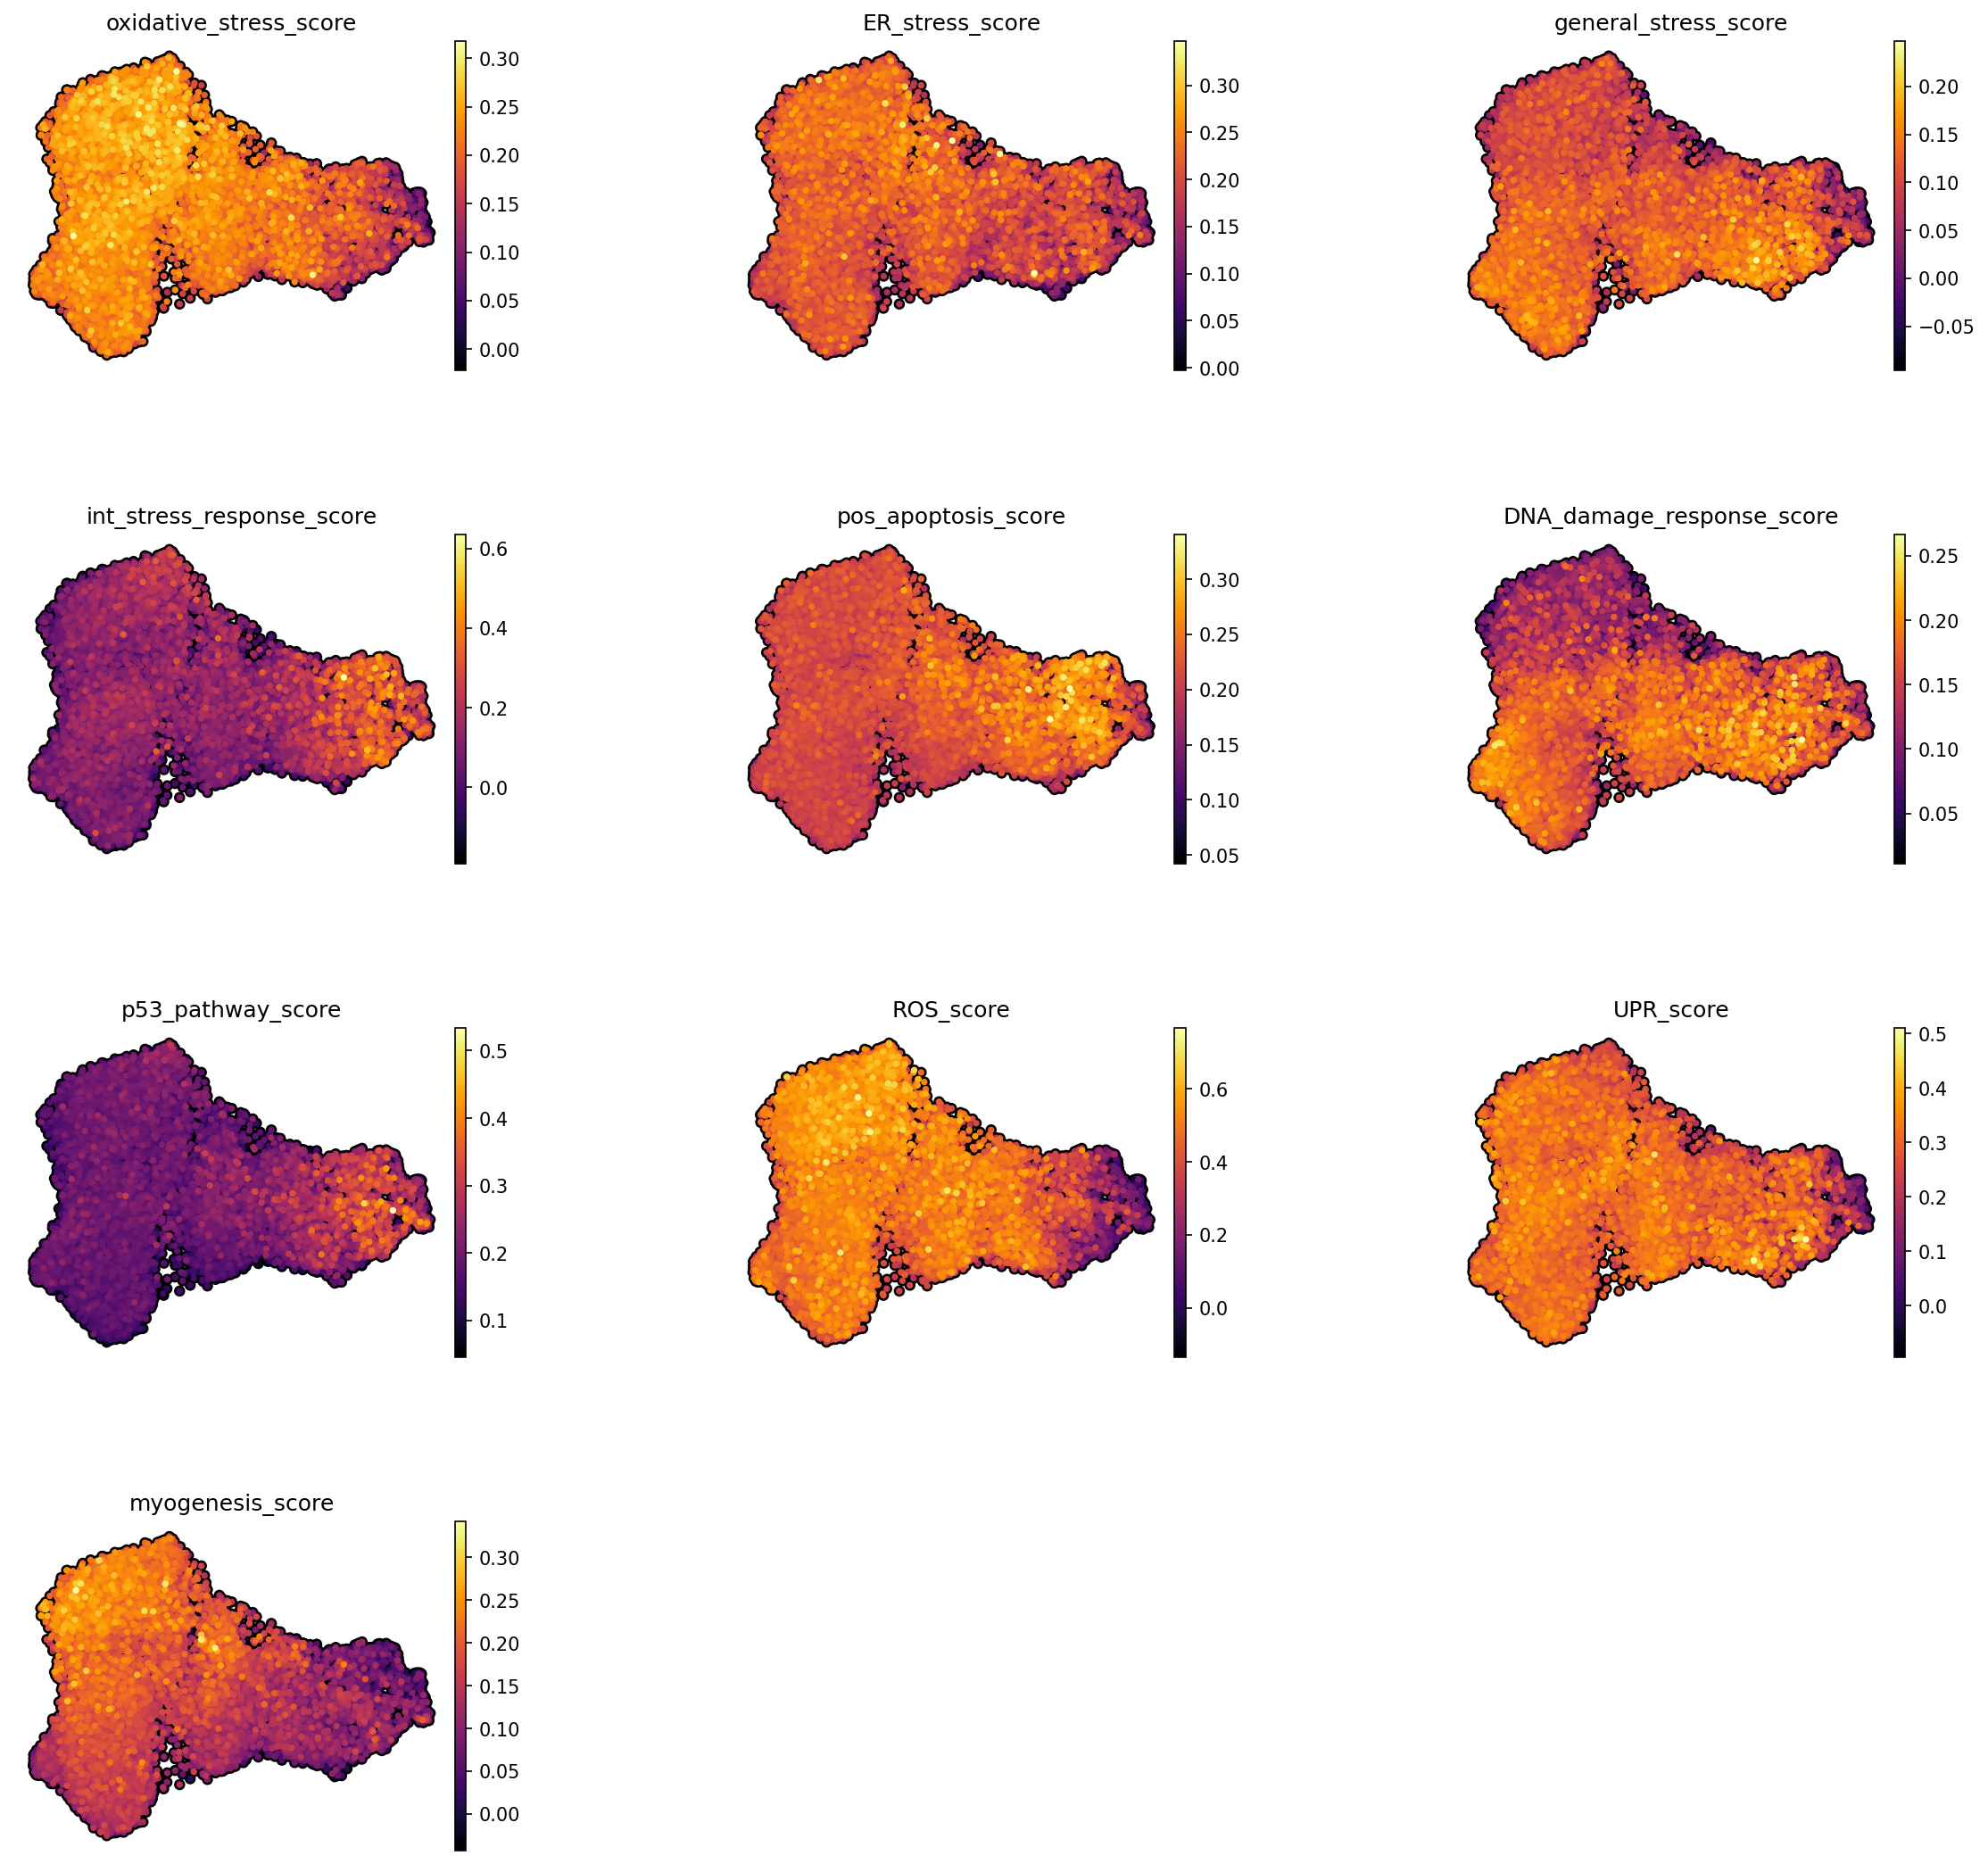

In [90]:
min_ctrl_size = 500

for geneset in cdf.columns:    
    
    score_name = f"{geneset}_score"
    
    # Skip if scores already exist
    if score_name in adata.obs.columns:
        print(f"Skipping {geneset}, scores already exist.")
        continue
        
    # get all genes belonging to geneset
    all_gene_list = cdf[geneset].unique()
    all_gene_list = [gene for gene in all_gene_list if gene in adata.var_names]
    
    # Set the ctrl_size to either 500 or the length of the gene list (whichever is larger)
    all_ctrl_size = max(min_ctrl_size, len(all_gene_list)) 
    
    # Score ALL genes in geneset
    sc.tl.score_genes(
        adata,
        gene_list=all_gene_list,
        score_name=score_name,
        ctrl_size=all_ctrl_size,
        use_raw=False,
        layer='log_norm',
    )


print("Finished.")


scores_to_plot = [col + '_score' for col in cdf.columns]

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=scores_to_plot,
    size=50,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    color_map='inferno',
    frameon=False,
    alpha=1,
    show=True,
    hspace=0.5,
    wspace=0.5,
)

In [91]:
df = adata.obs.copy()

cols_to_keep = ['pooled_condition', 'exp_level']
cols_to_keep = cols_to_keep + scores_to_plot

df = df[cols_to_keep]

print(df.shape)
df.head()

(16296, 12)


,pooled_condition,exp_level,oxidative_stress_score,ER_stress_score,general_stress_score,int_stress_response_score,pos_apoptosis_score,DNA_damage_response_score,p53_pathway_score,ROS_score,UPR_score,myogenesis_score
AAACCAAAGCAACTGC_hybrid,siPRRX1/mmMYOD1,high,0.210151,0.158203,0.109107,0.019430,0.195386,0.190214,0.121385,0.490255,0.249681,0.056490
AAACCAAAGTAGGGCA_hybrid,mmMYOD1,high,0.164168,0.113394,0.090958,-0.013820,0.167206,0.159346,0.173075,0.538198,0.260892,0.043034
AAACCAAAGTCTAGGC_hybrid,siPRRX1/mmMYOD1,low,0.197138,0.190847,0.065245,0.089027,0.230812,0.142944,0.194681,0.437670,0.274531,0.153173
AAACCATTCACGTAAT_hybrid,siPRRX1,NaN,0.149950,0.177128,0.094840,-0.099298,0.171976,0.115917,0.129313,0.469219,0.134569,0.102643
AAACCATTCAGGCAGA_hybrid,siPRRX1,NaN,0.160456,0.116770,0.097630,-0.048032,0.179363,0.152141,0.180260,0.372500,0.219241,0.117819


In [92]:
df["exp_level_group"] = np.where(
    df["pooled_condition"].eq("Control"),
    "Control",
    df["pooled_condition"].astype(str) + "_" + df["exp_level"].astype(str)
)

df.head()

,pooled_condition,exp_level,oxidative_stress_score,ER_stress_score,general_stress_score,int_stress_response_score,pos_apoptosis_score,DNA_damage_response_score,p53_pathway_score,ROS_score,UPR_score,myogenesis_score,exp_level_group
AAACCAAAGCAACTGC_hybrid,siPRRX1/mmMYOD1,high,0.210151,0.158203,0.109107,0.019430,0.195386,0.190214,0.121385,0.490255,0.249681,0.056490,siPRRX1/mmMYOD1_high
AAACCAAAGTAGGGCA_hybrid,mmMYOD1,high,0.164168,0.113394,0.090958,-0.013820,0.167206,0.159346,0.173075,0.538198,0.260892,0.043034,mmMYOD1_high
AAACCAAAGTCTAGGC_hybrid,siPRRX1/mmMYOD1,low,0.197138,0.190847,0.065245,0.089027,0.230812,0.142944,0.194681,0.437670,0.274531,0.153173,siPRRX1/mmMYOD1_low
AAACCATTCACGTAAT_hybrid,siPRRX1,NaN,0.149950,0.177128,0.094840,-0.099298,0.171976,0.115917,0.129313,0.469219,0.134569,0.102643,siPRRX1_nan
AAACCATTCAGGCAGA_hybrid,siPRRX1,NaN,0.160456,0.116770,0.097630,-0.048032,0.179363,0.152141,0.180260,0.372500,0.219241,0.117819,siPRRX1_nan


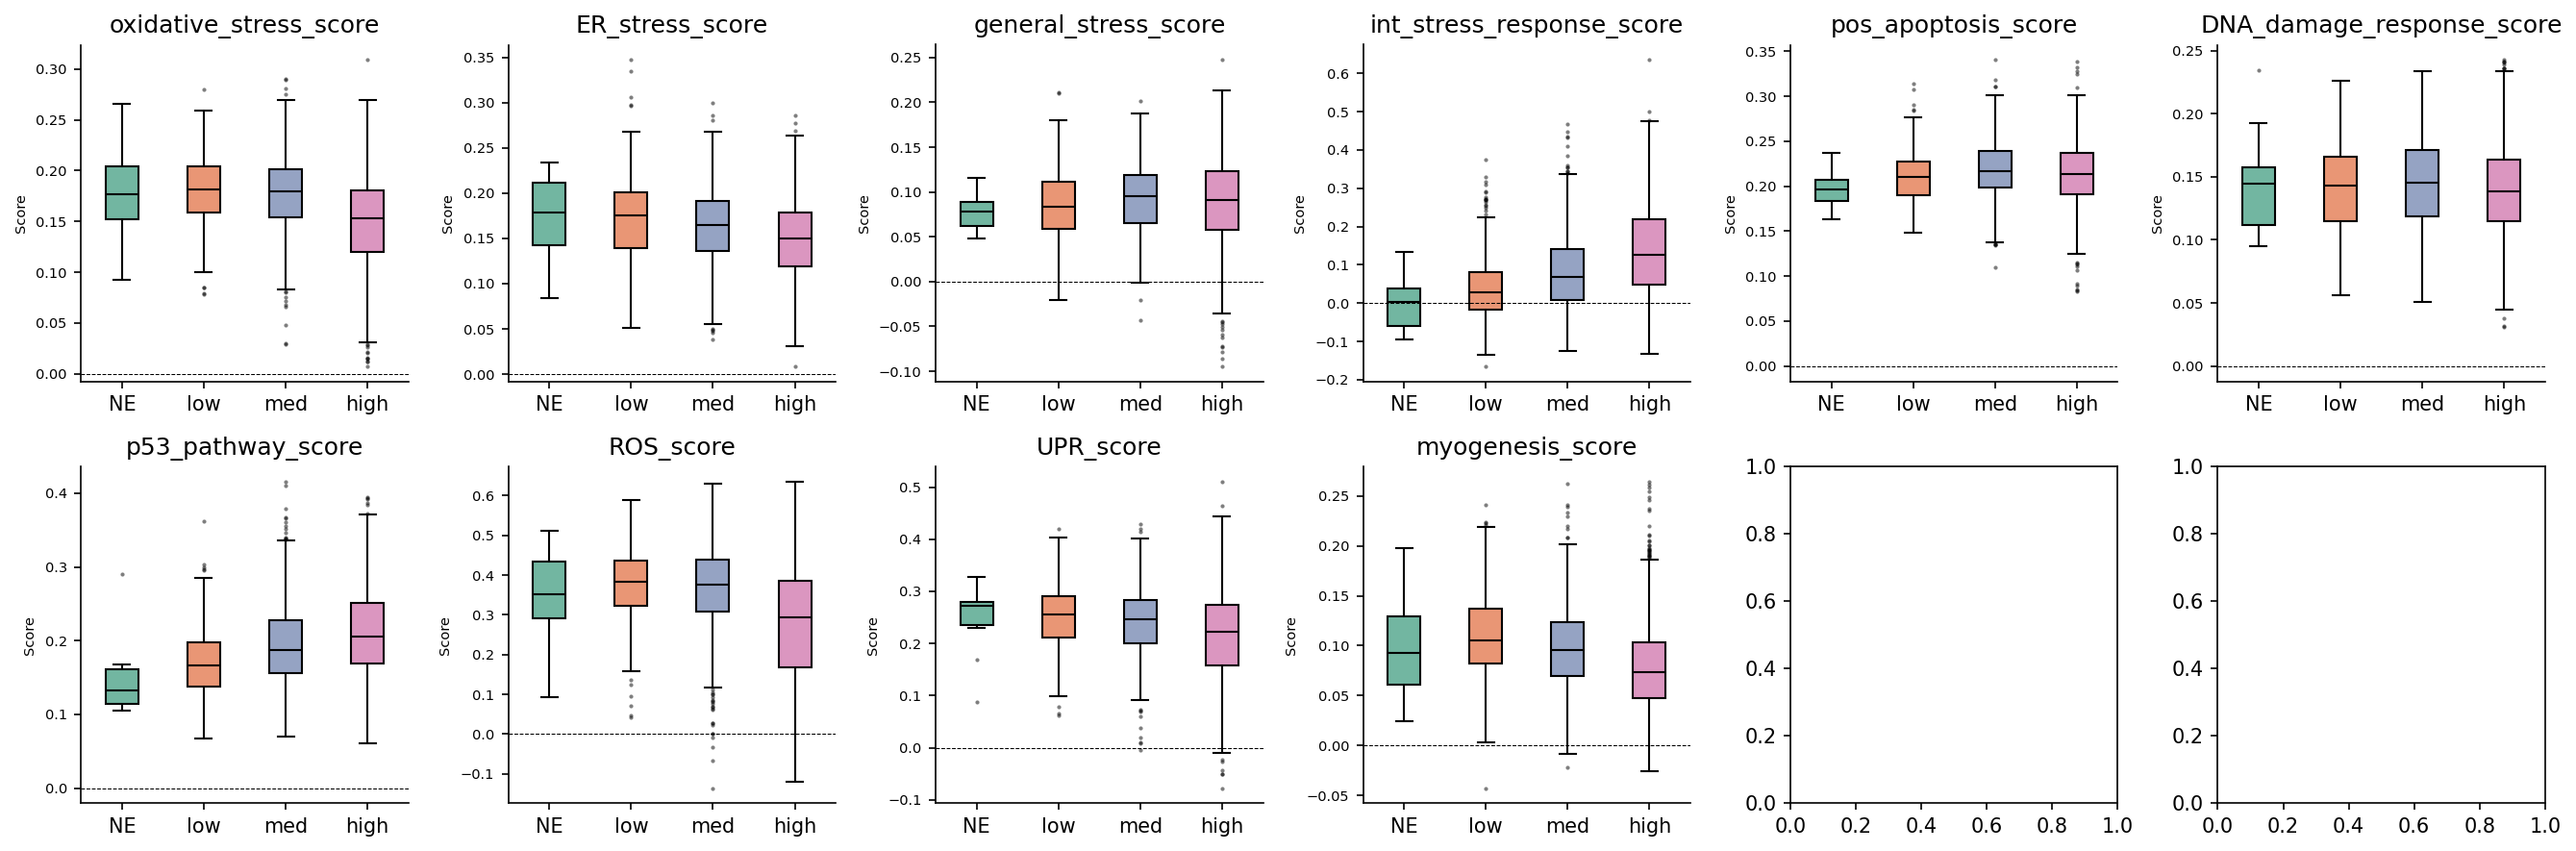

In [93]:
conditions = ['mmMYOD1']#, 'siPRRX1/mmMYOD1']
# conditions = ['siPRRX1/mmMYOD1']

tmp = df[df['pooled_condition'].isin(conditions)].copy()


ncols = 6
nrows = round(len(scores_to_plot)/ncols)


fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3, nrows*3), dpi=150)
axes = axes.flatten()

for i, score in enumerate(scores_to_plot):
    ax = axes[i]
    
    title = score
    
    sns.boxplot(
        data=tmp,
        x='exp_level',
        y=score,
        width=0.4,
        linecolor='k',
        hue='exp_level',
        palette='Set2',
        flierprops={'markersize': 1, 'alpha': 0.5},
        ax=ax,
        zorder=0,
    )
    
    ax.axhline(0, linestyle='--', linewidth=0.5, color='k', zorder=1)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("")
    # ax.set_xticks([])
    ax.set_ylabel("Score", fontsize=7)
    ax.tick_params(axis='y', labelsize=7)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

In [68]:
adata.obs["exp_level_group"] = np.where(
    adata.obs["pooled_condition"].eq("Control"),
    "Control",
    adata.obs["pooled_condition"].astype(str) + "_" + adata.obs["exp_level"].astype(str)
)

tdata = adata[adata.obs['pooled_condition'].isin(['mmMYOD1', 'siPRRX1/mmMYOD1']), :].copy()

tdata

AnnData object with n_obs × n_vars = 5711 × 25128
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'exp_level', 'oxidative_stress_score', 'ER_stress_score', 'general_stress_score', 'int_stress_response_score', 'pos_apoptosis_score', 'DNA_damage_response_score', 'exp_level_group'
    var: 'gene_id', 'gene_type', 'Chrom

In [71]:
tdata.obs['exp_level_group'] = tdata.obs['exp_level_group'].astype('category')

# cet orders
desired_order = [
    'mmMYOD1_high', 'siPRRX1/mmMYOD1_high',
    'mmMYOD1_med', 'siPRRX1/mmMYOD1_med',
    'mmMYOD1_low', 'siPRRX1/mmMYOD1_low',
    'mmMYOD1_NE', 'siPRRX1/mmMYOD1_NE',
]

tdata.obs['exp_level_group'] = tdata.obs['exp_level_group'].cat.reorder_categories(
    desired_order,
    ordered=True
)

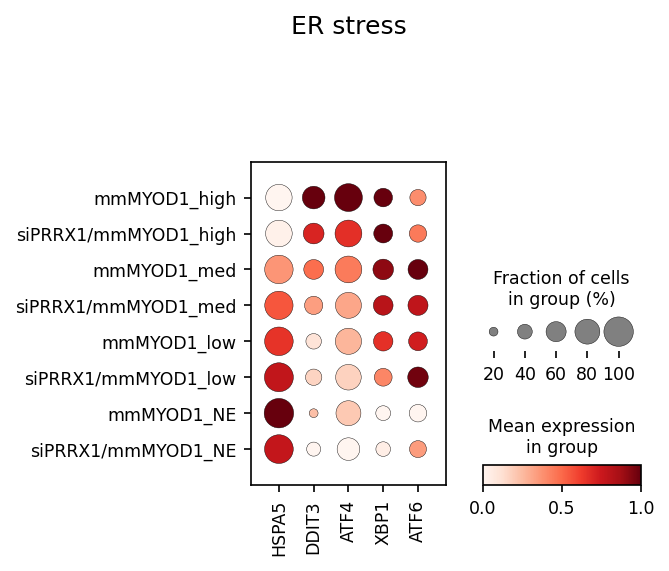

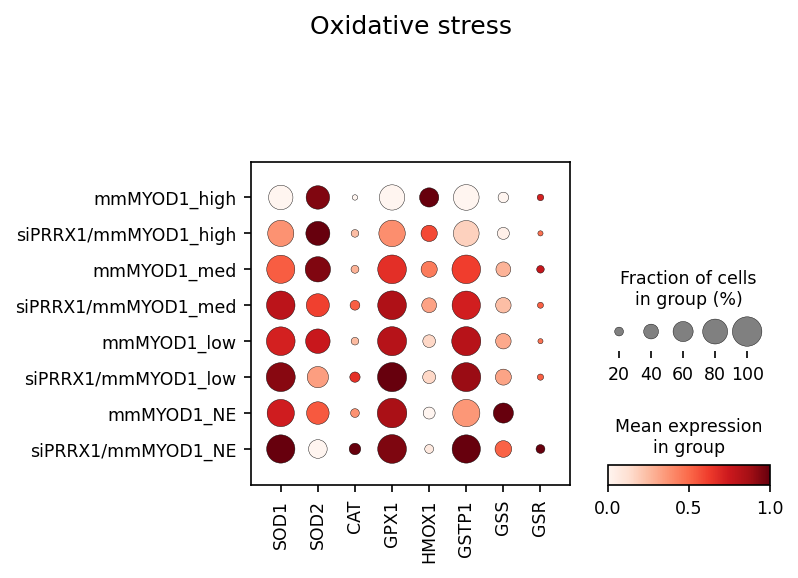

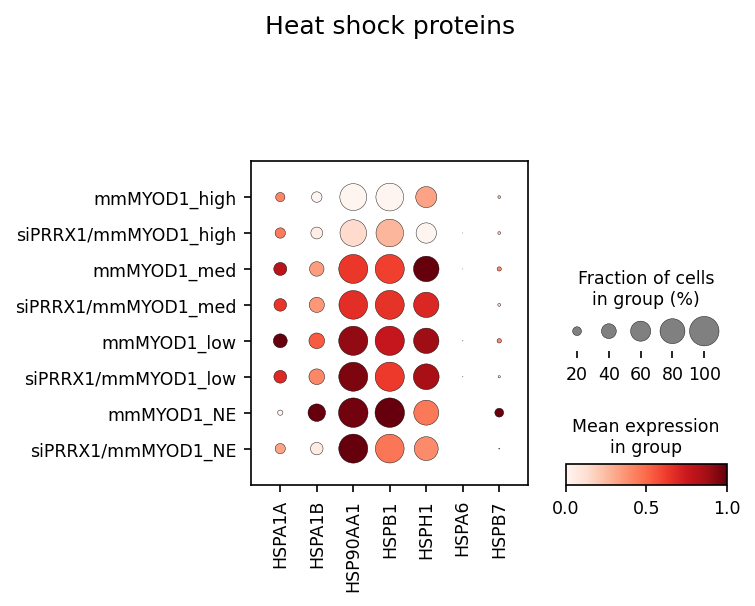

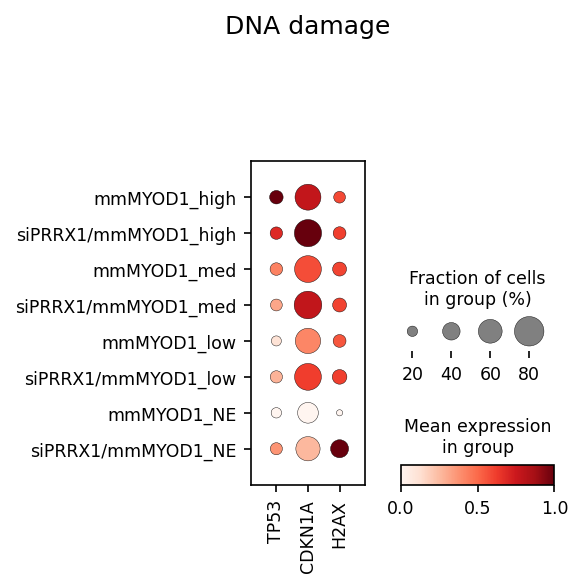

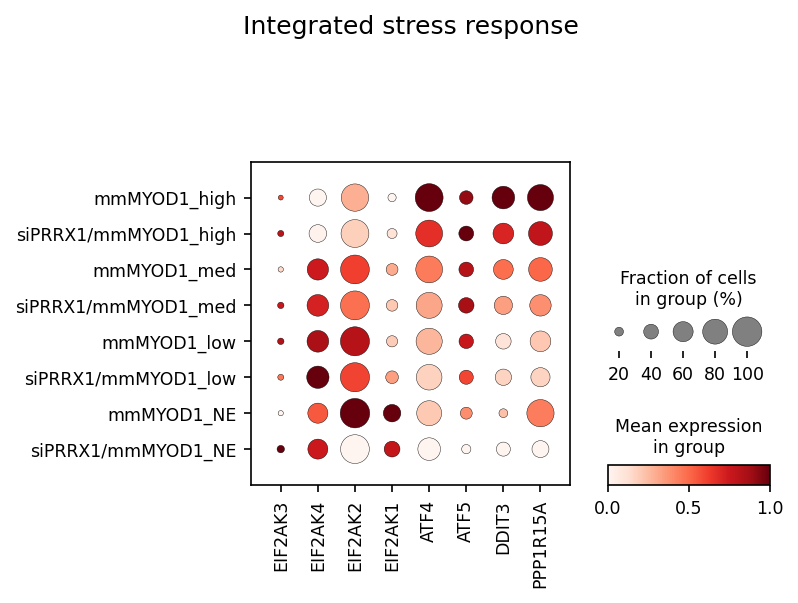

In [72]:
# plot specific genes
genes_of_interest = {
    'ER stress': ['HSPA5', 'DDIT3', 'ATF4', 'XBP1', 'IRE1', 'ATF6'],
    'Oxidative stress': ['SOD1', 'SOD2', 'CAT', 'GPX1', 'HMOX1', 'GSTP1', 'GSS', 'GSR'],
    'Heat shock proteins': ['HSP90', 'HSP70', 'HSP60', 'HSPA1A', 'HSPA1B', 'HSP90AA1', 'HSPB1', 'HSPH1', 'HSPA6', 'HSPB7', 'HSPB12'],
    'DNA damage': ['TP53', 'CDKN1A', 'GADD45RA', 'H2AX'],
    'Integrated stress response': ['EIF2AK3', 'EIF2AK4', 'EIF2AK2', 'EIF2AK1', 'ATF4', 'ATF5', 'DDIT3', 'PPP1R15A'],
}

for pathway, genes in genes_of_interest.items():
    
    genes_to_plot = [gene for gene in genes if gene in tdata.var_names]
    
    sc.pl.dotplot(
        tdata,
        groupby='exp_level_group',
        var_names=genes_to_plot,
        layer='log_norm',
        title=pathway,
        standard_scale='var',
    )

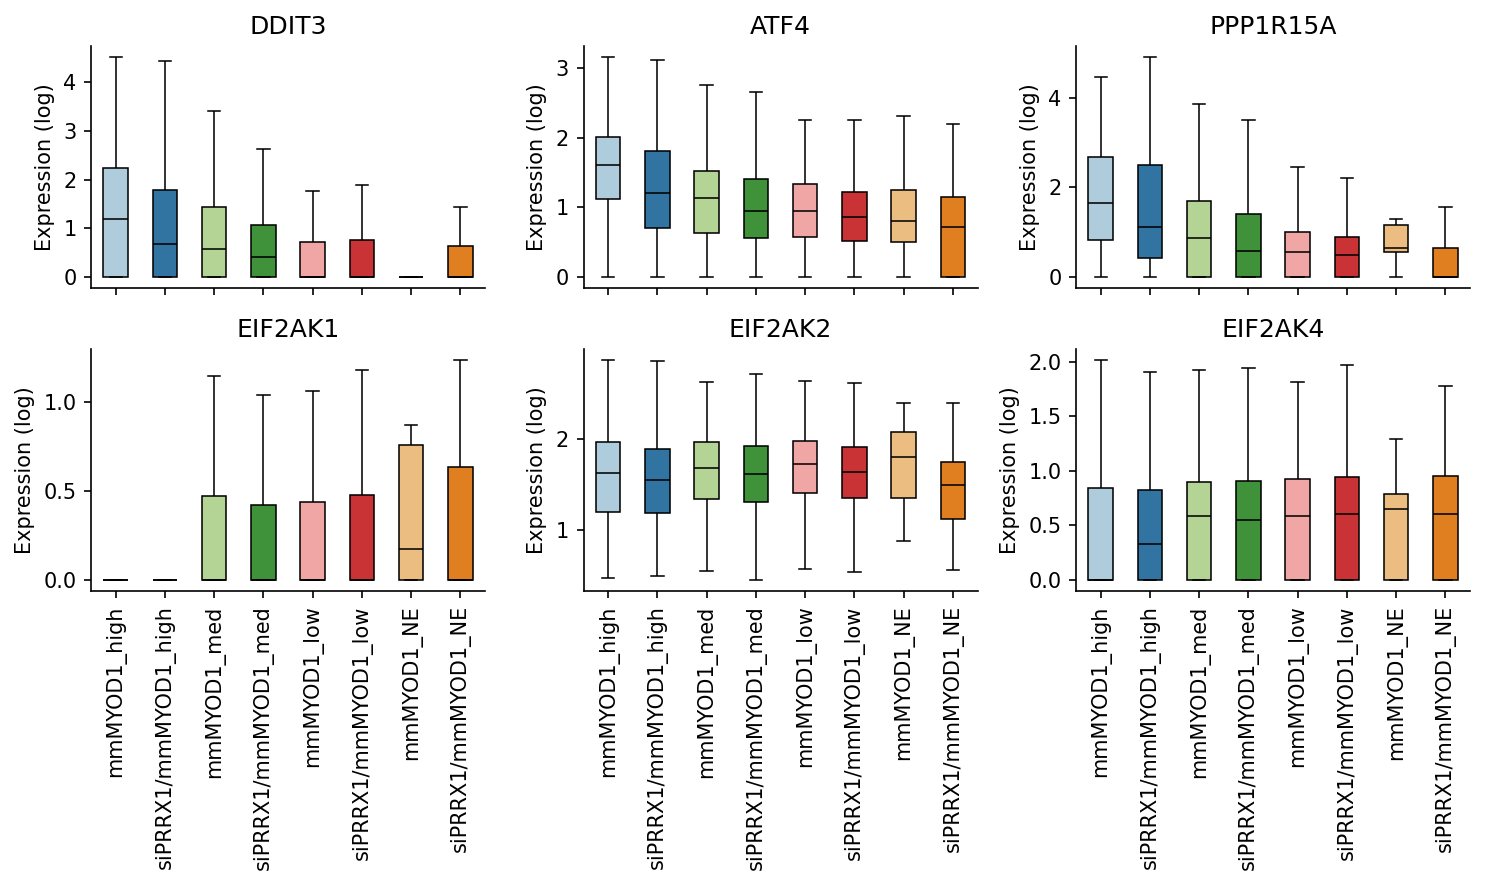

In [78]:
genes_to_plot = ['DDIT3', 'ATF4', 'PPP1R15A',
                 'EIF2AK1', 'EIF2AK2', 'EIF2AK4',
                ]


fig, axes = plt.subplots(2, 3, figsize=(10, 6), dpi=150, sharex=True)
axes = axes.flatten()

layer = 'log_norm'

for i, gene in enumerate(genes_to_plot):
    tdata.X = tdata.layers[layer].copy()
    gene_exp = tdata[:, gene].X.toarray().flatten()
    groups = tdata.obs['exp_level_group']
    data = pd.DataFrame({'expression': gene_exp, 'group': groups})

    sns.boxplot(
        data=data,
        x='group',
        y='expression',
        hue='group',
        order=desired_order,
        hue_order=desired_order,
        width=0.5,
        linewidth=0.75,
        linecolor='k',
        showfliers=False,
        palette='Paired',
        # palette=palette,
        ax=axes[i],
        legend=False,
    )
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=90)
    
    axes[i].set_title(gene)
    
    if layer == 'log_norm':
        axes[i].set_ylabel("Expression (log)")
        # axes[i].axhline(y=5, ls='--', color='k', lw=0.5, zorder=0)
    else:
        axes[i].set_ylabel("Raw counts")
    # axes[i].set_title(gene)
    # axes[i].set_ylim([-0.75, 6.5])
    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()